<a href="https://colab.research.google.com/github/juheesun/-/blob/main/%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C_%EC%9D%B4%EC%9B%83%EA%B8%B0%EB%B0%98_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
최적 파라미터(K=30)로 최종 평가 시작...

       [최종 테스트 결과 (ua.test)]
  - 알고리즘: User-based CF
  - 최적 이웃 수 (K): 30
  - 최종 RMSE: 0.9656
  - 최종 MAE : 0.7528


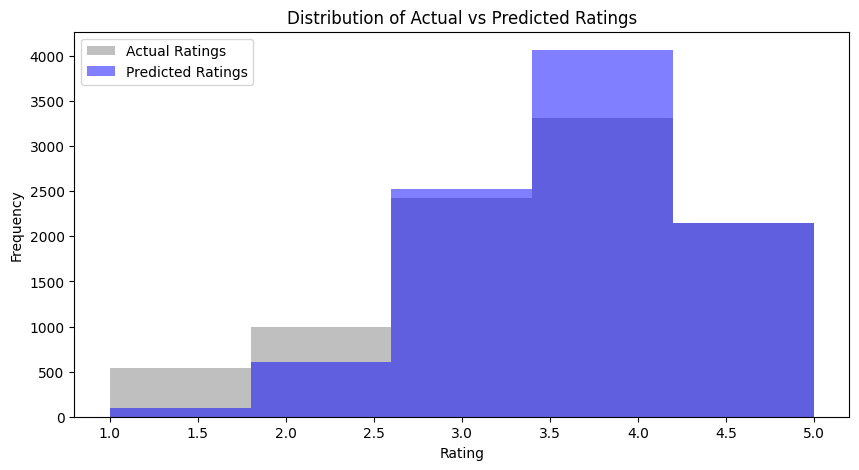

In [1]:
import pandas as pd
import numpy as np
import pickle
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from google.colab import drive

# 1. 드라이브 마운트 및 경로 설정
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Recommender_systems/ml-100k/'

# 2. 저장된 모델 데이터 로드 (학습 단계에서 저장한 최적 모델)
with open(base_path + 'model_final_v3.pkl', 'rb') as f:
    model = pickle.load(f)

# 모델 구성 요소 추출
train_matrix = model['train_matrix']
train_matrix_centered = model['train_matrix_centered']
user_sim_df = model['user_sim']
user_mean = model['user_mean']
best_k = model['best_k']  # 학습에서 결정된 30

# 3. 테스트 데이터 로드 (ua.test)
test_data = pd.read_csv(base_path + 'ua.test', sep='\t', names=['user_id', 'item_id', 'rating', 'ts'])

# 4. 최종 예측 함수 (최적화된 User-based 전용)
def predict_final(user_id, item_id, k):
    # 훈련셋에 없는 유저나 아이템일 경우 전체 평균 또는 유저 평균으로 대응 (Cold Start 방어)
    if user_id not in user_sim_df.index or item_id not in train_matrix.columns:
        return user_mean.get(user_id, 3.0)

    sim_scores = user_sim_df[user_id]
    # 해당 아이템에 평점을 남긴 다른 유저들 추출
    rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
    # 그중 나와 가장 유사한 Top-K 추출
    top_k_users = sim_scores[rated_users].sort_values(ascending=False).head(k)

    if top_k_users.abs().sum() == 0:
        return user_mean[user_id]

    # 가중치 합산 예측
    weighted_diff = np.dot(top_k_users, train_matrix_centered.loc[top_k_users.index, item_id])
    prediction = user_mean[user_id] + (weighted_diff / top_k_users.abs().sum())

    # 평점 범위 제한 (1~5점)
    return max(1.0, min(5.0, prediction))

# 5. 테스트 데이터 전체에 대해 예측 수행
print(f"최적 파라미터(K={best_k})로 최종 평가 시작...")
final_preds = [predict_final(u, i, best_k) for u, i in zip(test_data['user_id'], test_data['item_id'])]

# 6. 최종 성능 지표 계산
final_rmse = math.sqrt(mean_squared_error(test_data['rating'], final_preds))
final_mae = mean_absolute_error(test_data['rating'], final_preds)

print("\n" + "="*40)
print("       [최종 테스트 결과 (ua.test)]")
print("="*40)
print(f"  - 알고리즘: User-based CF")
print(f"  - 최적 이웃 수 (K): {best_k}")
print(f"  - 최종 RMSE: {final_rmse:.4f}")
print(f"  - 최종 MAE : {final_mae:.4f}")
print("="*40)

# 7. 시각화: 실제 평점 vs 예측 평점 분포 비교
plt.figure(figsize=(10, 5))
plt.hist(test_data['rating'], bins=5, alpha=0.5, label='Actual Ratings', color='gray')
plt.hist(final_preds, bins=5, alpha=0.5, label='Predicted Ratings', color='blue')
plt.title('Distribution of Actual vs Predicted Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.legend()
plt.show()